KHÁM PHÁ DỮ LIỆU

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imagehash
from PIL import Image
from collections import defaultdict
from tqdm import tqdm
import random
import hashlib

TẬP        | LỚP             | SỐ ẢNH     | KÍCH THƯỚC ĐIỂN HÌNH (H, W)
train      | fresh           | 1144       | (4160, 3120)
train      | rotten          | 1144       | (144, 176)
test       | fresh           | 490        | (3120, 4160)
test       | rotten          | 490        | (144, 176)


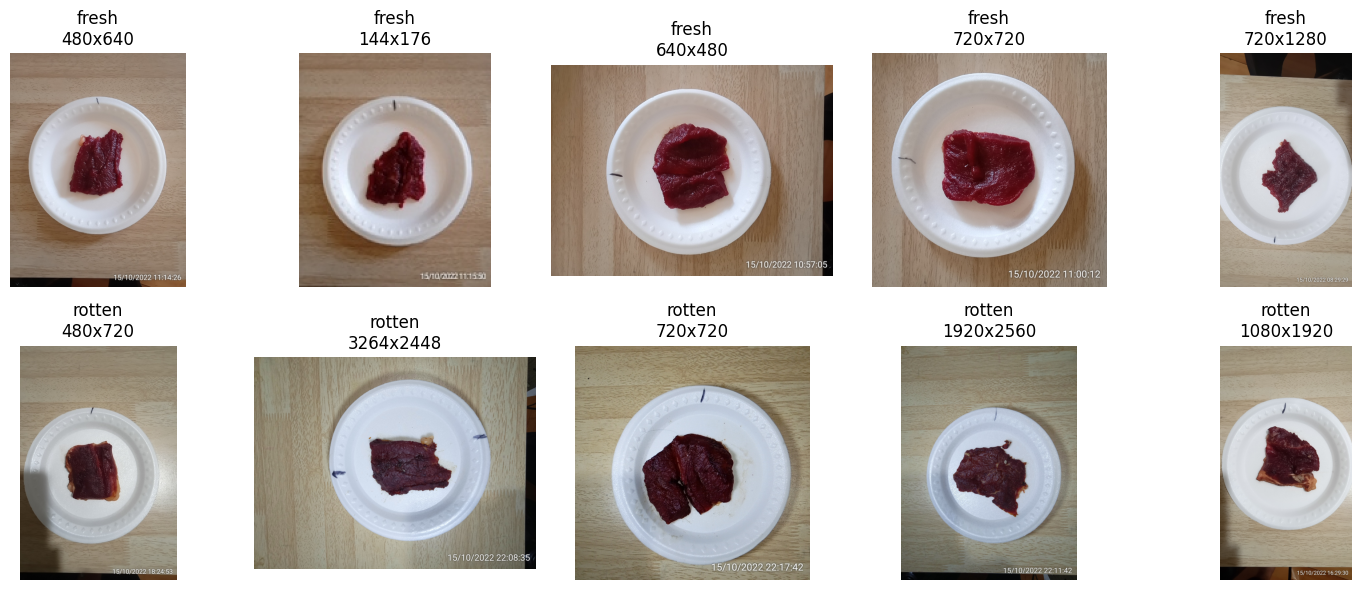

In [2]:
# 1. Thông tin dữ liệu
data_path = r'D:/Do_An/Data_Raw'  

# Các thư mục con
train_dir = os.path.join(data_path, 'train')
test_dir  = os.path.join(data_path, 'test')

print(f"{'TẬP':<10} | {'LỚP':<15} | {'SỐ ẢNH':<10} | {'KÍCH THƯỚC ĐIỂN HÌNH (H, W)'}")

stats = []
size_info = defaultdict(list)  # Lưu kích thước để phân tích sau
bad_files = []

for split in ['train', 'test']:
    split_dir = os.path.join(data_path, split)
    if not os.path.exists(split_dir):
        continue
    for label in ['fresh', 'rotten']:
        folder = os.path.join(split_dir, label)
        if not os.path.exists(folder):
            continue
            
        images = [f for f in os.listdir(folder) if f.lower().endswith('.jpg')]
        count = len(images)
        
        # Lấy kích thước của 5 ảnh đầu tiên để xác định kích thước điển hình
        sizes = []
        for img_name in images[:5]:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                h, w = img.shape[:2]
                sizes.append((h, w))
                size_info[label].append((w, h, w/h))  # width, height, aspect ratio
        
        typical_size = sizes[0] if sizes else "N/A"
        
        print(f"{split:<10} | {label:<15} | {count:<10} | {typical_size}")
        
        stats.append({
            'Tập': split,
            'Nhãn': label,
            'Số lượng': count
        })

df_stats = pd.DataFrame(stats)

# Hiển thị mẫu ảnh
n_samples = 5
classes = ['fresh', 'rotten']

# Tạo khung vẽ
fig, axes = plt.subplots(len(classes), n_samples, figsize=(15, 6))

for i, label in enumerate(classes):
    # Đường dẫn thư mục con
    folder_path = os.path.join(train_dir, label)
    
    # Lấy danh sách tất cả file ảnh
    all_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Chọn ngẫu nhiên
    selected_files = random.sample(all_files, min(len(all_files), n_samples))
    
    for j, img_name in enumerate(selected_files):
        img_path = os.path.join(folder_path, img_name)
        
        # Đọc và hiển thị ảnh
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Chuyển BGR -> RGB
            
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{label}\n{img.shape[1]}x{img.shape[0]}") # Hiển thị kích thước WxH
            axes[i, j].axis('off')
        else:
            axes[i, j].text(0.5, 0.5, "Lỗi file", ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# 2. Xem có ảnh lỗi không
if len(bad_files) > 0:
    print("\n" + "="*80)
    print(f"PHÁT HIỆN {len(bad_files)} ẢNH LỖI! (Nên xóa ngay)")
    print("="*80)
    for path, reason in bad_files:
        print(f"- {reason}: {path}")
else:
    print("\nKhông phát hiện file lỗi nào.")


Không phát hiện file lỗi nào.


In [4]:
# 3. Phát hiện ảnh trùng lặp và rò rỉ 
print("\nĐang kiểm tra ảnh trùng lặp và rò rỉ dữ liệu (train ↔ test)...")

hash_dict = {}
leakage_examples = []
duplicate_in_split = []

def get_hash(img_path):
    try:
        with Image.open(img_path) as img:
            return str(imagehash.phash(img))
    except:
        # Nếu lỗi, dùng hash file để tránh crash
        with open(img_path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()

# --- PHẦN QUÉT (GIỮ NGUYÊN) ---
for split, split_dir in [('train', train_dir), ('test', test_dir)]:
    for label in ['fresh', 'rotten']:
        folder = os.path.join(split_dir, label)
        if not os.path.exists(folder): continue
        
        # Dùng tqdm nếu muốn hiện thanh tiến trình, không thì dùng os.listdir bình thường
        # for img_name in tqdm(os.listdir(folder), desc=f"Scanning {split}/{label}"): 
        for img_name in os.listdir(folder):
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')): continue
            
            img_path = os.path.join(folder, img_name)
            h = get_hash(img_path)
            
            if h in hash_dict:
                prev_split, prev_label, prev_name = hash_dict[h]
                if prev_split != split:  # Rò rỉ giữa train và test
                    # Lưu lại đường dẫn ảnh hiện tại để xử lý sau
                    leakage_examples.append((img_path, prev_split, prev_label, prev_name))
                else:  # Trùng trong cùng split
                    duplicate_in_split.append((img_path, prev_name))
            else:
                hash_dict[h] = (split, label, img_name)

leakage_count = len(leakage_examples)
duplicate_count = len(duplicate_in_split)

print(f"   → Ảnh trùng trong cùng tập (train hoặc test): {duplicate_count}")
print(f"   → Ảnh rò rỉ giữa train và test: {leakage_count}")

# --- PHẦN MỚI THÊM: LƯU VÀO FILE (KHÔNG XÓA) ---
blacklist_path = 'blacklist.txt'
print(f"\nĐang lưu danh sách các file lỗi vào '{blacklist_path}'...")

with open(blacklist_path, 'w', encoding='utf-8') as f:
    # 1. Ghi header để dễ đọc (tùy chọn)
    f.write("# Danh sach file can xoa (Leakage & Duplicate)\n")
    
    # 2. Ghi danh sách Rò rỉ
    for item in leakage_examples:
        # item[0] là đường dẫn ảnh
        f.write(f"{item[0]}\n")
        
    # 3. Ghi danh sách Trùng lặp
    for item in duplicate_in_split:
        f.write(f"{item[0]}\n")

print(f"HOÀN TẤT! Đã lưu {leakage_count + duplicate_count} đường dẫn ảnh vào file blacklist.txt.")


Đang kiểm tra ảnh trùng lặp và rò rỉ dữ liệu (train ↔ test)...
   → Ảnh trùng trong cùng tập (train hoặc test): 355
   → Ảnh rò rỉ giữa train và test: 103

Đang lưu danh sách các file lỗi vào 'blacklist.txt'...
HOÀN TẤT! Đã lưu 458 đường dẫn ảnh vào file blacklist.txt.


In [5]:
# 4. Xem thông số màu sắc VÀ Kích thước
print("Đang trích xuất thông tin...")

stats = [] 
train_dir = os.path.join(data_path, 'train')

for label in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, label)
    if not os.path.isdir(class_dir): continue
    
    files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg'))]
    
    for file in files:
        try:
            img_path = os.path.join(class_dir, file)
            img = cv2.imread(img_path)
            if img is None: continue

            # --- 1. TÍNH KÍCH THƯỚC ---
            h, w = img.shape[:2]
            aspect_ratio = w / h

            # --- 2. TÍNH MÀU SẮC ---
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            r_channel = img_rgb[:, :, 0].astype(float)
            g_channel = img_rgb[:, :, 1].astype(float)
            mean_pure_red = np.mean(r_channel - g_channel)

            img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            mean_s = np.mean(img_hsv[:, :, 1])
            mean_v = np.mean(img_hsv[:, :, 2]) # Brightness

            # Lưu tất cả vào 1 từ điển
            stats.append({
                'Label': label,
                'Pure_Red': mean_pure_red,
                'Saturation': mean_s,
                'Brightness': mean_v,
                'Aspect_Ratio': aspect_ratio, 
                'Width': w,
                'Height': h
            })
        except Exception as e:
            continue

# Tạo DataFrame tổng
df_full = pd.DataFrame(stats)

df_colors = df_full 
df_sizes = df_full  

print(f"Đã xử lý xong {len(df_full)} ảnh.")
df_full.head()

Đang trích xuất thông tin...
Đã xử lý xong 2288 ảnh.


,Label,Pure_Red,Saturation,Brightness,Aspect_Ratio,Width,Height
0,fresh,6.221645,50.808037,145.725546,0.750000,3120,4160
1,fresh,10.037542,49.415230,169.754724,1.777778,1920,1080
2,fresh,16.450033,66.620827,144.452868,0.750000,480,640
3,fresh,15.768764,65.403637,145.749216,0.666667,480,720
4,fresh,14.526335,65.225002,145.839780,1.000000,720,720


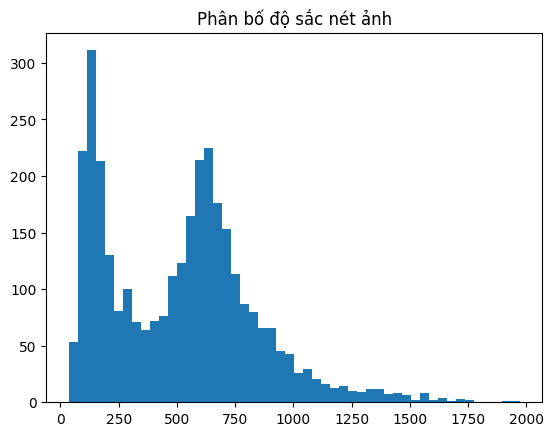

In [6]:
# 5. Phân bố độ sắc nét ảnh
def blur_score(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

scores = []
for root,_,files in os.walk(data_path):
    for f in files:
        if f.endswith('.jpg'):
            img = cv2.imread(os.path.join(root,f))
            if img is not None:
                scores.append(blur_score(img))

plt.hist(scores, bins=50)
plt.title("Phân bố độ sắc nét ảnh")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7564\2225887768.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sizes, x='Label', y='Aspect_Ratio', ax=ax5, palette={'fresh': 'green', 'rotten': 'red'})


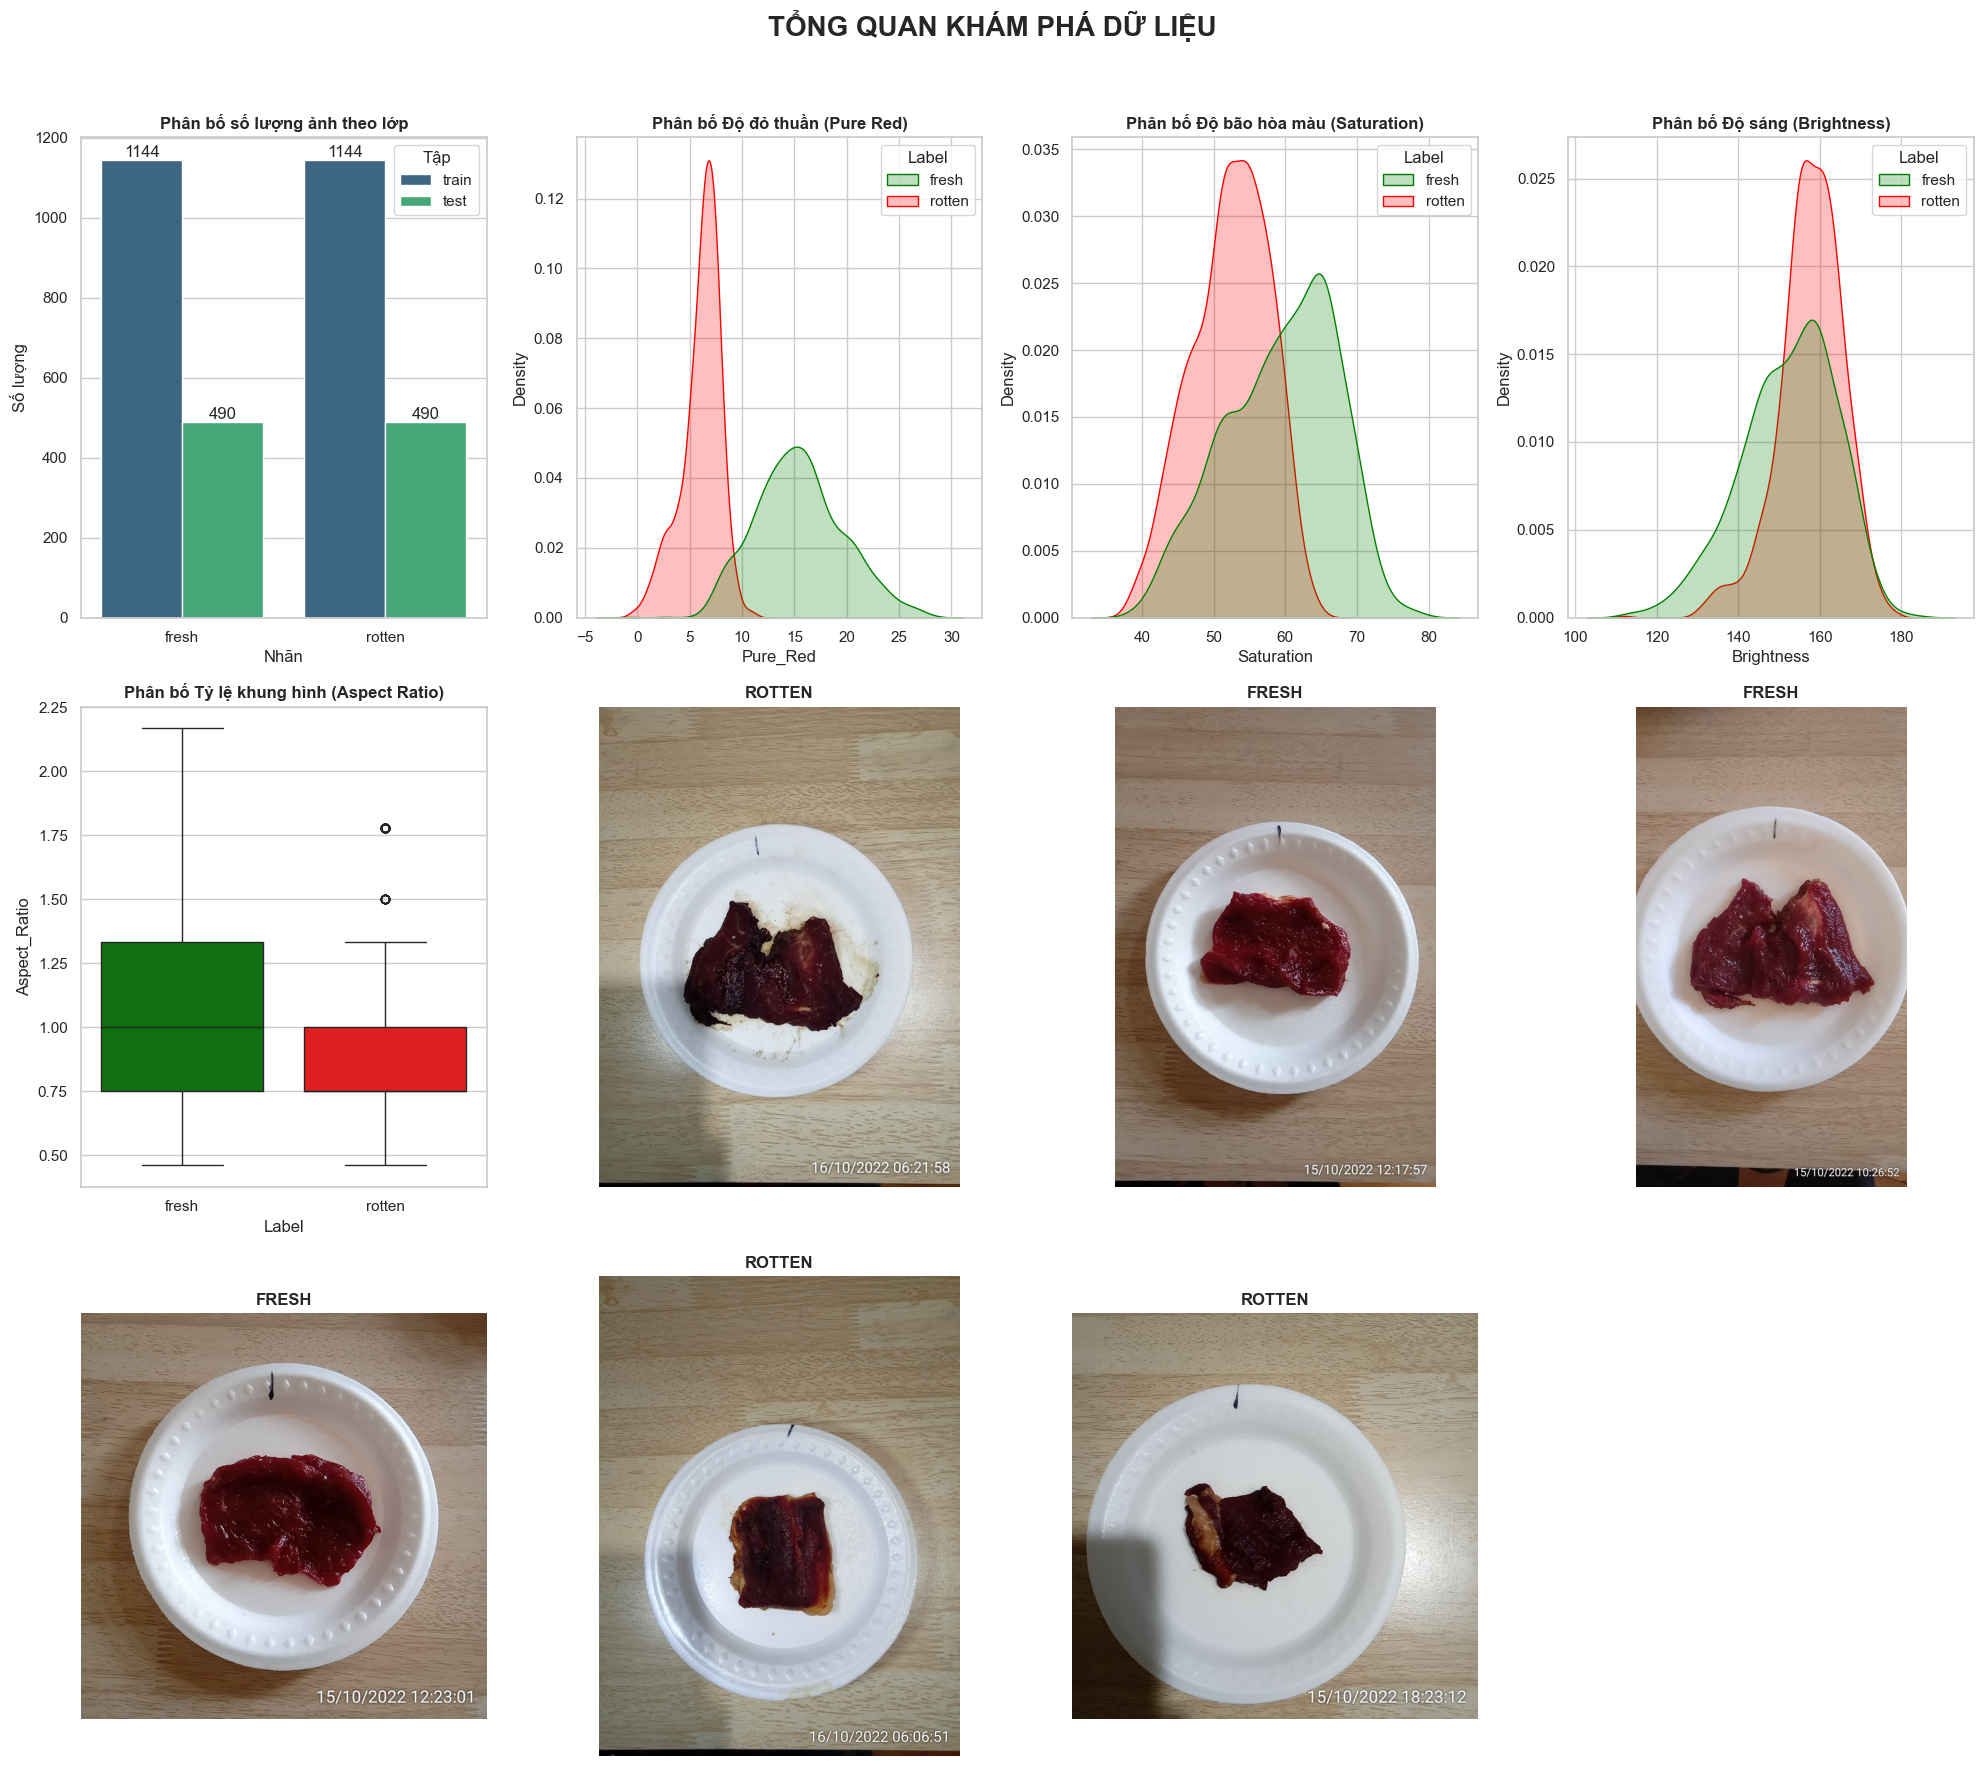

In [7]:
# 6. Biểu đồ trực quan hóa
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(20, 18))

# 1. Cân bằng lớp
ax1 = fig.add_subplot(3, 4, 1)
sns.barplot(data=df_stats, x='Nhãn', y='Số lượng', hue='Tập', ax=ax1, palette='viridis')
ax1.set_title("Phân bố số lượng ảnh theo lớp", fontweight='bold')
for c in ax1.containers:
    ax1.bar_label(c, fmt='%d')

# 2. Pure Red (độ đỏ thuần)
ax2 = fig.add_subplot(3, 4, 2)
sns.kdeplot(data=df_colors, x='Pure_Red', hue='Label', fill=True, ax=ax2,
            palette={'fresh': 'green', 'rotten': 'red'})
ax2.set_title("Phân bố Độ đỏ thuần (Pure Red)", fontweight='bold')

# 3. Saturation
ax3 = fig.add_subplot(3, 4, 3)
sns.kdeplot(data=df_colors, x='Saturation', hue='Label', fill=True, ax=ax3,
            palette={'fresh': 'green', 'rotten': 'red'})
ax3.set_title("Phân bố Độ bão hòa màu (Saturation)", fontweight='bold')

# 4. Brightness
ax4 = fig.add_subplot(3, 4, 4)
sns.kdeplot(data=df_colors, x='Brightness', hue='Label', fill=True, ax=ax4,
            palette={'fresh': 'green', 'rotten': 'red'})
ax4.set_title("Phân bố Độ sáng (Brightness)", fontweight='bold')

# 5. Aspect Ratio
ax5 = fig.add_subplot(3, 4, 5)
sns.boxplot(data=df_sizes, x='Label', y='Aspect_Ratio', ax=ax5, palette={'fresh': 'green', 'rotten': 'red'})
ax5.set_title("Phân bố Tỷ lệ khung hình (Aspect Ratio)", fontweight='bold')

# 6-11. Ảnh mẫu (3 fresh + 3 rotten)
plot_idx = 6
display_samples = []

for label in ['fresh', 'rotten']:
    folder_train = os.path.join(train_dir, label)
    folder_test = os.path.join(test_dir, label)
    all_imgs = []
    if os.path.exists(folder_train):
        all_imgs += [os.path.join(folder_train, f) for f in os.listdir(folder_train) if f.endswith('.jpg')]
    if os.path.exists(folder_test):
        all_imgs += [os.path.join(folder_test, f) for f in os.listdir(folder_test) if f.endswith('.jpg')]
    
    chosen = random.sample(all_imgs, min(3, len(all_imgs)))
    display_samples.extend([(label, p) for p in chosen])

random.shuffle(display_samples)

for i in range(min(6, len(display_samples))):
    ax = fig.add_subplot(3, 4, plot_idx + i)
    label, path = display_samples[i]
    img = cv2.imread(path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"{label.upper()}", fontsize=12, fontweight='bold')
        ax.axis('off')

plt.suptitle("TỔNG QUAN KHÁM PHÁ DỮ LIỆU", fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [8]:
# 7. BÁO CÁO TỔNG HỢP
print("BÁO CÁO TỔNG HỢP KHÁM PHÁ DỮ LIỆU (EDA)")

total_fresh = df_stats[df_stats['Nhãn']=='fresh']['Số lượng'].sum()
total_rotten = df_stats[df_stats['Nhãn']=='rotten']['Số lượng'].sum()

print(f"1. Cân bằng dữ liệu:")
print(f"   • Fresh : {total_fresh} ảnh")
print(f"   • Rotten: {total_rotten} ảnh")
print(f"   → {' Dữ liệu cân bằng tốt' if abs(total_fresh - total_rotten) < 100 else 'Bị lệch'}")

print(f"\n2. Rò rỉ dữ liệu (data leakage):")
print(f"   • Số ảnh trùng giữa train và test: {leakage_count}")
print(f"   → {'AN TOÀN' if leakage_count == 0 else 'CẢNH BÁO: Có rò rỉ! Cần xóa ảnh trùng trong test'}")

print(f"\n3. Phân bố màu sắc:")
mean_pure_red_f = df_colors[df_colors['Label']=='fresh']['Pure_Red'].mean()
mean_pure_red_r = df_colors[df_colors['Label']=='rotten']['Pure_Red'].mean()
mean_sat_f = df_colors[df_colors['Label']=='fresh']['Saturation'].mean()
mean_sat_r = df_colors[df_colors['Label']=='rotten']['Saturation'].mean()

print(f"   • Độ đỏ thuần (Pure Red)  - Fresh: {mean_pure_red_f:.1f} | Rotten: {mean_pure_red_r:.1f}")
print(f"   • Độ bão hòa (Saturation) - Fresh: {mean_sat_f:.1f} | Rotten: {mean_sat_r:.1f}")
print(f"   → Thịt tươi thường đỏ và tươi hơn.")

print(f"\n4. Kích thước ảnh:")
print(f"   • Fresh : Thường rất lớn (~3000-4000px), tỷ lệ ~4:3")
print(f"   • Rotten: Thường rất nhỏ (~150px), tỷ lệ ~1:1.2")
print(f"   → Đồng bộ RESIZE tất cả về cùng kích thước 224x224")

print(f"\n5. Tổng kết:")
print(f"   • Resize tất cả ảnh về 224x224")
print(f"   • Data augmentation mạnh giảm bias kích thước/màu")
print(f"   • Xóa ảnh trùng trong test vì có rò rỉ dữ liệu")


BÁO CÁO TỔNG HỢP KHÁM PHÁ DỮ LIỆU (EDA)
1. Cân bằng dữ liệu:
   • Fresh : 1634 ảnh
   • Rotten: 1634 ảnh
   →  Dữ liệu cân bằng tốt

2. Rò rỉ dữ liệu (data leakage):
   • Số ảnh trùng giữa train và test: 103
   → CẢNH BÁO: Có rò rỉ! Cần xóa ảnh trùng trong test

3. Phân bố màu sắc:
   • Độ đỏ thuần (Pure Red)  - Fresh: 15.4 | Rotten: 6.1
   • Độ bão hòa (Saturation) - Fresh: 59.3 | Rotten: 52.3
   → Thịt tươi thường đỏ và tươi hơn.

4. Kích thước ảnh:
   • Fresh : Thường rất lớn (~3000-4000px), tỷ lệ ~4:3
   • Rotten: Thường rất nhỏ (~150px), tỷ lệ ~1:1.2
   → Đồng bộ RESIZE tất cả về cùng kích thước 224x224

5. Tổng kết:
   • Resize tất cả ảnh về 224x224
   • Data augmentation mạnh giảm bias kích thước/màu
   • Xóa ảnh trùng trong test vì có rò rỉ dữ liệu
